##Exploratory data analysis for GSS

Imports:

In [1]:
import os
import pandas as pd
import numpy as np

!pip install pyreadstat
import pyreadstat

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.0 MB/s eta 0:00:00


In [2]:
gss = pd.read_spss('GSS2024.sav')

In [3]:
print(gss.columns.to_list())
gss.head()

['fileversion', 'year', 'id', 'abany', 'abanyg', 'abdefect', 'abdefectg', 'abhelp1', 'abhelp2', 'abhelp3', 'abhelp4', 'abhlth', 'abhlthg', 'abmoral', 'abnomore', 'abnomoreg', 'abpoor', 'abpoorg', 'abrape', 'abrapeg', 'absingle', 'absingleg', 'acpttg', 'adcoumed', 'addoc', 'adfam', 'adminconsent', 'adoptus', 'adpsy', 'adtch', 'adults', 'adultsinhh', 'adults_exp', 'advisor1', 'advisor2', 'advisor3', 'advisor4', 'advisor5', 'affrmact', 'afraidof', 'age', 'agekdbrn', 'agetech', 'aidrive', 'aimed', 'aimofart', 'aiworry', 'allergic', 'amancstr', 'ambetter', 'ambornin', 'amchrstn', 'amcit', 'amcitizn', 'amfeel', 'amgovt', 'amownway', 'amshamed', 'amtv', 'aneseligible', 'anespost_status', 'anespre_status', 'angry', 'ashamed', 'attend', 'babies', 'babies_exp', 'badchar', 'ballot', 'batch', 'befair', 'belikeus', 'biasnews', 'bible', 'biblenv', 'biblev', 'bird', 'bizmoney', 'born', 'breakdwn', 'brneffrt', 'broadband', 'bullied', 'bullpeer', 'cantrust', 'cappun', 'cat', 'cctv', 'charactr', 'chemba

,fileversion,year,id,abany,abanyg,abdefect,abdefectg,abhelp1,abhelp2,abhelp3,...,wtssps_next,xmarsex,xmovie,xmoviey,xnorcsiz,yousup,baselinestatus,amerstatus,wtssps_as,wtssnrps_as
0,GSS 1972-2024 Release 3a (July 2026),2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,yes,NaN,a suburb of a medium size central city,NaN,yes,no,NaN,1.663284
1,GSS 1972-2024 Release 3a (July 2026),2024.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,several times a year,a suburb of a medium size central city,NaN,yes,no,NaN,1.506088
2,GSS 1972-2024 Release 3a (July 2026),2024.0,3.0,yes,yes,NaN,yes,yes,yes,yes,...,1.125411,always wrong,no,NaN,a suburb of a medium size central city,NaN,yes,no,NaN,1.363951
3,GSS 1972-2024 Release 3a (July 2026),2024.0,4.0,no,NaN,no,NaN,NaN,NaN,NaN,...,NaN,always wrong,NaN,NaN,a suburb of a medium size central city,NaN,yes,no,NaN,3.796158
4,GSS 1972-2024 Release 3a (July 2026),2024.0,5.0,no,no,NaN,no,NaN,NaN,NaN,...,NaN,always wrong,no,NaN,a suburb of a medium size central city,NaN,yes,no,NaN,1.504431


Get subset of GSS columns that are relevant to job satisfaction & clean them

In [4]:
cols = [
    # target
    'satjob',
    # work status / hours / filter
    'wrkstat', 'hrs1', 'hrs2',
    # compensation & standing
    'realrinc', 'conrinc', 'income', 'income16', 'satfin',
    # occupation
    'prestg10', 'sei10', 'occ10', 'indus10',
    # job quality / autonomy / meaning
    'wrksup', 'union', 'jobsecok', 'promte7', 'flexhrs',
    'freedom', 'richwork', 'wrkhome', 'learnnew', 'creative', 'useful',
    # demographics / controls
    'age', 'sex', 'race', 'educ', 'degree', 'marital', 'region', 'class'
]

cols = [c for c in cols if c in gss.columns]

df = gss[cols].copy()

In [5]:
import numpy as np

satisfaction_mapping = {
    'very dissatisfied': 1,
    'moderately dissatisfied': 2,
    'a little dissatisfied': 3,
    'neither satisfied nor dissatisfied': 4,
    'a little satisfied': 5,
    'moderately satisfied': 6,
    'very satisfied': 7,
    'nan': np.nan # Map the string 'nan' to actual NaN
}

# Clean the 'satjob' column: convert to string, strip whitespace, and convert to lowercase
df.loc[:, 'satjob_cleaned'] = df['satjob'].astype(str).str.strip().str.lower()

print("Unique values in 'satjob' after cleaning:")
print(df['satjob_cleaned'].unique())
print("Mapping keys:")
print(list(satisfaction_mapping.keys()))

# Apply the mapping to the cleaned 'satjob' column to create a new numerical column.
# Using .loc to modify the DataFrame safely and avoid potential SettingWithCopyWarning.
df.loc[:, 'satjob_numeric'] = df['satjob_cleaned'].map(satisfaction_mapping)

# Apply winsorization to the new numerical 'satjob_numeric' column.
# Use nan_policy='omit' to perform winsorization only on non-NaN values,
# and then propagate the NaNs back to their original positions.
df.loc[:, 'job_satisfaction'] = stats.mstats.winsorize(
    df['satjob_numeric'],
    limits=[0.01, 0.01],
    nan_policy='omit'
)

Unique values in 'satjob' after cleaning:
['moderately satisfied' 'nan' 'very satisfied' 'a little dissatisfied'
 'very dissatisfied']
Mapping keys:
['very dissatisfied', 'moderately dissatisfied', 'a little dissatisfied', 'neither satisfied nor dissatisfied', 'a little satisfied', 'moderately satisfied', 'very satisfied', 'nan']


### Job Satisfaction Distribution

Descriptive statistics for job_satisfaction:


/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4809: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,job_satisfaction
count,2782.000000
mean,5.852624
std,1.608765
min,1.000000
25%,6.000000
50%,6.000000
75%,7.000000
max,7.000000


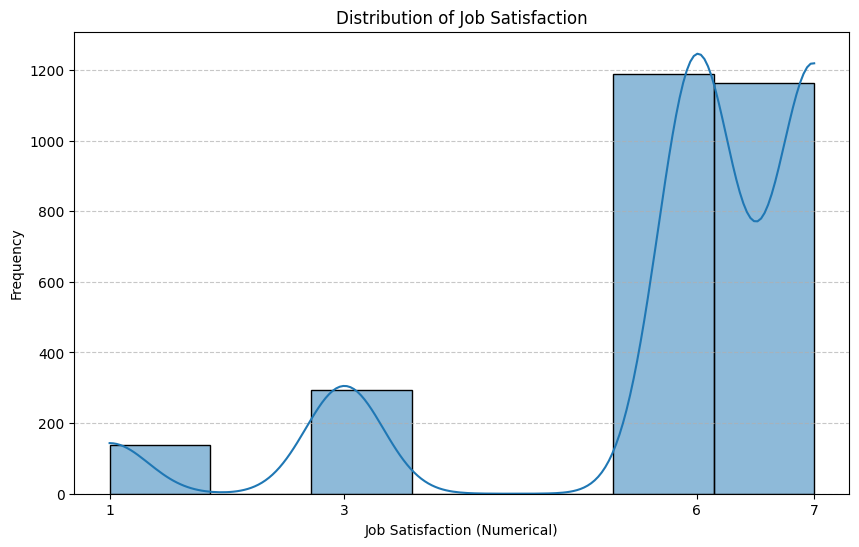


Value counts for original `satjob` column:


,count
satjob,
NaN,1204
moderately satisfied,1188
very satisfied,1162
a little dissatisfied,294
very dissatisfied,138



Value counts for `satjob_numeric` column (after mapping):


,count
satjob_numeric,
NaN,1204
6.0,1188
7.0,1162
3.0,294
1.0,138


In [6]:
print('Descriptive statistics for job_satisfaction:')
display(df['job_satisfaction'].describe())

# Visualize the distribution of the 'job_satisfaction' column
plt.figure(figsize=(10, 6))
sns.histplot(df['job_satisfaction'], bins=7, kde=True)
plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction (Numerical)')
plt.ylabel('Frequency')
plt.xticks(sorted(df['job_satisfaction'].dropna().unique()))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('\nValue counts for original `satjob` column:')
display(df['satjob'].value_counts(dropna=False))

print('\nValue counts for `satjob_numeric` column (after mapping):')
display(df['satjob_numeric'].value_counts(dropna=False))

### Handling Missing Values

In [7]:
# Calculate the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a DataFrame for missing values and sort it
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Percentage of Missing Values per Column:")
display(missing_info)

Percentage of Missing Values per Column:


,Missing Count,Missing Percentage
hrs2,3914,98.193678
richwork,2315,58.078274
hrs1,1785,44.781736
conrinc,1641,41.169092
realrinc,1641,41.169092
union,1359,34.094330
satjob,1204,30.205720
job_satisfaction,1204,30.205720
satjob_numeric,1204,30.205720
income,423,10.612142


### Re-evaluating Missing Values after Fixes

In [8]:
# Calculate the percentage of missing values for each column again
missing_values_after_fix = df.isnull().sum()
missing_percentage_after_fix = (missing_values_after_fix / len(df)) * 100

# Create a DataFrame for missing values and sort it
missing_info_after_fix = pd.DataFrame({
    'Missing Count': missing_values_after_fix,
    'Missing Percentage': missing_percentage_after_fix
})
missing_info_after_fix = missing_info_after_fix[missing_info_after_fix['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Percentage of Missing Values per Column (After Job Satisfaction Fix):")
display(missing_info_after_fix)

Percentage of Missing Values per Column (After Job Satisfaction Fix):


,Missing Count,Missing Percentage
hrs2,3914,98.193678
richwork,2315,58.078274
hrs1,1785,44.781736
conrinc,1641,41.169092
realrinc,1641,41.169092
union,1359,34.094330
satjob,1204,30.205720
job_satisfaction,1204,30.205720
satjob_numeric,1204,30.205720
income,423,10.612142


### Imputing Missing Values for Columns with Low Percentages

In [9]:
# Identify columns with low missing percentages (e.g., < 5%)
low_missing_cols = missing_info_after_fix[missing_info_after_fix['Missing Percentage'] < 5].index.tolist()

# Exclude 'satjob_cleaned', 'satjob_numeric', 'job_satisfaction' as their missingness is tied to original 'satjob'
low_missing_cols = [col for col in low_missing_cols if col not in ['satjob_cleaned', 'satjob_numeric', 'job_satisfaction', 'satjob']]

print(f"Columns to impute: {low_missing_cols}")

for col in low_missing_cols:
    if df[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[col]):
        # Impute categorical columns with mode
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed '{col}' with mode: {mode_val}")
    elif pd.api.types.is_numeric_dtype(df[col]):
        # Impute numerical columns with median
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed '{col}' with median: {median_val}")

# Verify that missing values in these columns are handled
print("\nMissing values after imputation for low-percentage columns:")
display(df[low_missing_cols].isnull().sum())

Columns to impute: ['age', 'race', 'class', 'educ', 'sex', 'satfin', 'marital', 'wrkstat', 'degree']


/tmp/ipykernel_4053/303049591.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_4053/303049591.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


Imputed 'age' with mode: 37.0
Imputed 'race' with mode: white
Imputed 'class' with mode: middle class
Imputed 'educ' with mode: 12th grade
Imputed 'sex' with mode: female
Imputed 'satfin' with mode: more or less satisfied
Imputed 'marital' with mode: married
Imputed 'wrkstat' with mode: working full time
Imputed 'degree' with mode: high school

Missing values after imputation for low-percentage columns:


,0
age,0
race,0
class,0
educ,0
sex,0
satfin,0
marital,0
wrkstat,0
degree,0


### Handling Remaining Missing Values

Some columns still have a high percentage of missing values after the initial imputation for low-percentage columns. For columns with **more than 90% missing values**, I will drop them, as they are unlikely to contribute meaningfully to the analysis. For columns with **moderate missing percentages (between 20% and 90%)**, I will impute them using the median for numerical features and the mode for categorical features.

Columns to be dropped due to very high missing percentages:
- `income`
- `conrinc`
- `realrinc`
- `income16`
- `hrs2`
- `wrkhome`

In [10]:
# Re-calculate missing info after imputing low-percentage columns
current_missing_values = df.isnull().sum()
current_missing_percentage = (current_missing_values / len(df)) * 100

missing_info_after_imputation = pd.DataFrame({
    'Missing Count': current_missing_values,
    'Missing Percentage': current_missing_percentage
})
missing_info_after_imputation = missing_info_after_imputation[missing_info_after_imputation['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Identify columns with >90% missing values based on the updated missing info
high_missing_cols_to_drop = missing_info_after_imputation[missing_info_after_imputation['Missing Percentage'] > 90].index.tolist()

print(f"Columns to drop due to >90% missing values: {high_missing_cols_to_drop}")

df = df.drop(columns=high_missing_cols_to_drop)

# Re-calculate missing info after dropping high-missing columns
missing_values_after_drop = df.isnull().sum()
missing_percentage_after_drop = (missing_values_after_drop / len(df)) * 100

missing_info_after_drop = pd.DataFrame({
    'Missing Count': missing_values_after_drop,
    'Missing Percentage': missing_percentage_after_drop
})
missing_info_after_drop = missing_info_after_drop[missing_info_after_drop['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nMissing values after dropping high-percentage columns:")
display(missing_info_after_drop)

Columns to drop due to >90% missing values: ['hrs2']

Missing values after dropping high-percentage columns:


,Missing Count,Missing Percentage
richwork,2315,58.078274
hrs1,1785,44.781736
conrinc,1641,41.169092
realrinc,1641,41.169092
union,1359,34.094330
satjob,1204,30.205720
job_satisfaction,1204,30.205720
satjob_numeric,1204,30.205720
income16,423,10.612142
income,423,10.612142


Imputing the remaining columns that still have missing values (those with 20-90% missing, and `hrs1` and `job_satisfaction` which have low missing percentages but were not part of the `low_missing_cols` in the previous step).

For numerical columns, we use the **median**, and for categorical columns, the **mode**.

In [11]:
# Identify remaining columns with missing values to impute
remaining_missing_cols = missing_info_after_drop.index.tolist()

print(f"Columns to impute (remaining): {remaining_missing_cols}")

for col in remaining_missing_cols:
    if df[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[col]):
        # Impute categorical columns with mode
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed '{col}' with mode: {mode_val}")
    elif pd.api.types.is_numeric_dtype(df[col]):
        # Impute numerical columns with median
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed '{col}' with median: {median_val}")

# Verify that all missing values are handled
print("\nMissing values after final imputation:")
display(df.isnull().sum().sum()) # Should be 0

Columns to impute (remaining): ['richwork', 'hrs1', 'conrinc', 'realrinc', 'union', 'satjob', 'job_satisfaction', 'satjob_numeric', 'income16', 'income', 'indus10', 'occ10', 'prestg10', 'sei10']
Imputed 'richwork' with mode: continue to work
Imputed 'hrs1' with mode: 40.0
Imputed 'conrinc' with mode: 38002.49999999999


/tmp/ipykernel_4053/3743505783.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[col]):
/tmp/ipykernel_4053/3743505783.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


Imputed 'realrinc' with mode: 24502.5
Imputed 'union' with mode: no, neither belong
Imputed 'satjob' with mode: moderately satisfied


/tmp/ipykernel_4053/3743505783.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


Imputed 'job_satisfaction' with median: 6.0
Imputed 'satjob_numeric' with median: 6.0
Imputed 'income16' with mode: $170,000 or over
Imputed 'income' with mode: $25,000 or more
Imputed 'indus10' with mode: elementary and secondary schools
Imputed 'occ10' with mode: managers, all other
Imputed 'prestg10' with mode: 35.0
Imputed 'sei10' with median: 41.1

Missing values after final imputation:


np.int64(0)

### Final Check of Missing Values

After dropping columns with high missing percentages and imputing the remaining, let's confirm that there are no more missing values in the dataset.

In [12]:
# Calculate the percentage of missing values for each column one last time
final_missing_values = df.isnull().sum()
final_missing_percentage = (final_missing_values / len(df)) * 100

final_missing_info = pd.DataFrame({
    'Missing Count': final_missing_values,
    'Missing Percentage': final_missing_percentage
})
final_missing_info = final_missing_info[final_missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Final Percentage of Missing Values per Column:")
display(final_missing_info)

if final_missing_info.empty:
    print("\nAll missing values have been successfully handled!")
else:
    print("\nSome missing values still remain. Please review the output.")

Final Percentage of Missing Values per Column:


,Missing Count,Missing Percentage



All missing values have been successfully handled!


### Updated Job Satisfaction Distribution

Descriptive statistics for job_satisfaction after imputation:


,job_satisfaction
count,3986.00000
mean,5.89714
std,1.34564
min,1.00000
25%,6.00000
50%,6.00000
75%,7.00000
max,7.00000


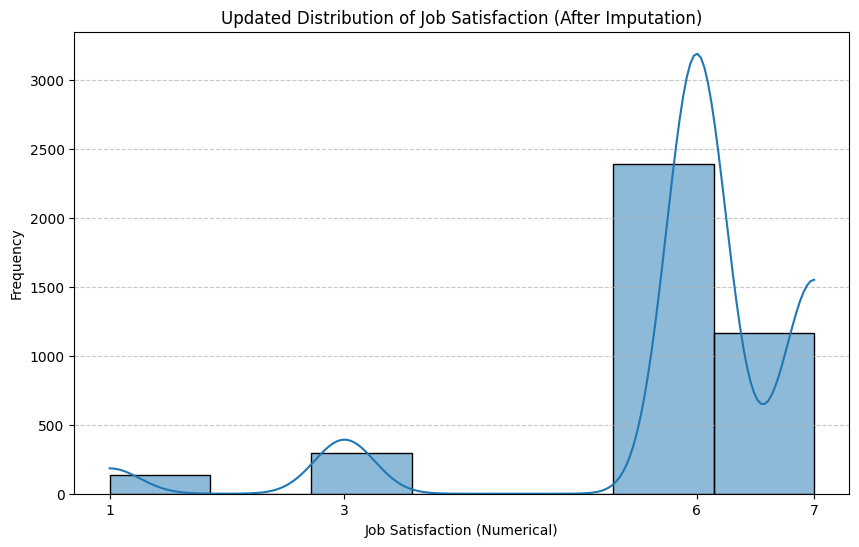

In [13]:
print('Descriptive statistics for job_satisfaction after imputation:')
display(df['job_satisfaction'].describe())

# Visualize the distribution of the 'job_satisfaction' column
plt.figure(figsize=(10, 6))
sns.histplot(df['job_satisfaction'], bins=7, kde=True)
plt.title('Updated Distribution of Job Satisfaction (After Imputation)')
plt.xlabel('Job Satisfaction (Numerical)')
plt.ylabel('Frequency')
plt.xticks(sorted(df['job_satisfaction'].dropna().unique()))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Exploring Categorical Features

Now that missing values have been addressed, let's examine the distributions of the key categorical features in our dataset. This will help us understand the composition of our sample and identify any imbalances or interesting patterns.

/tmp/ipykernel_4053/1831318699.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_4053/1831318699.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_4053/1831318699.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_4053/1831318699.py:11: FutureWarning: 



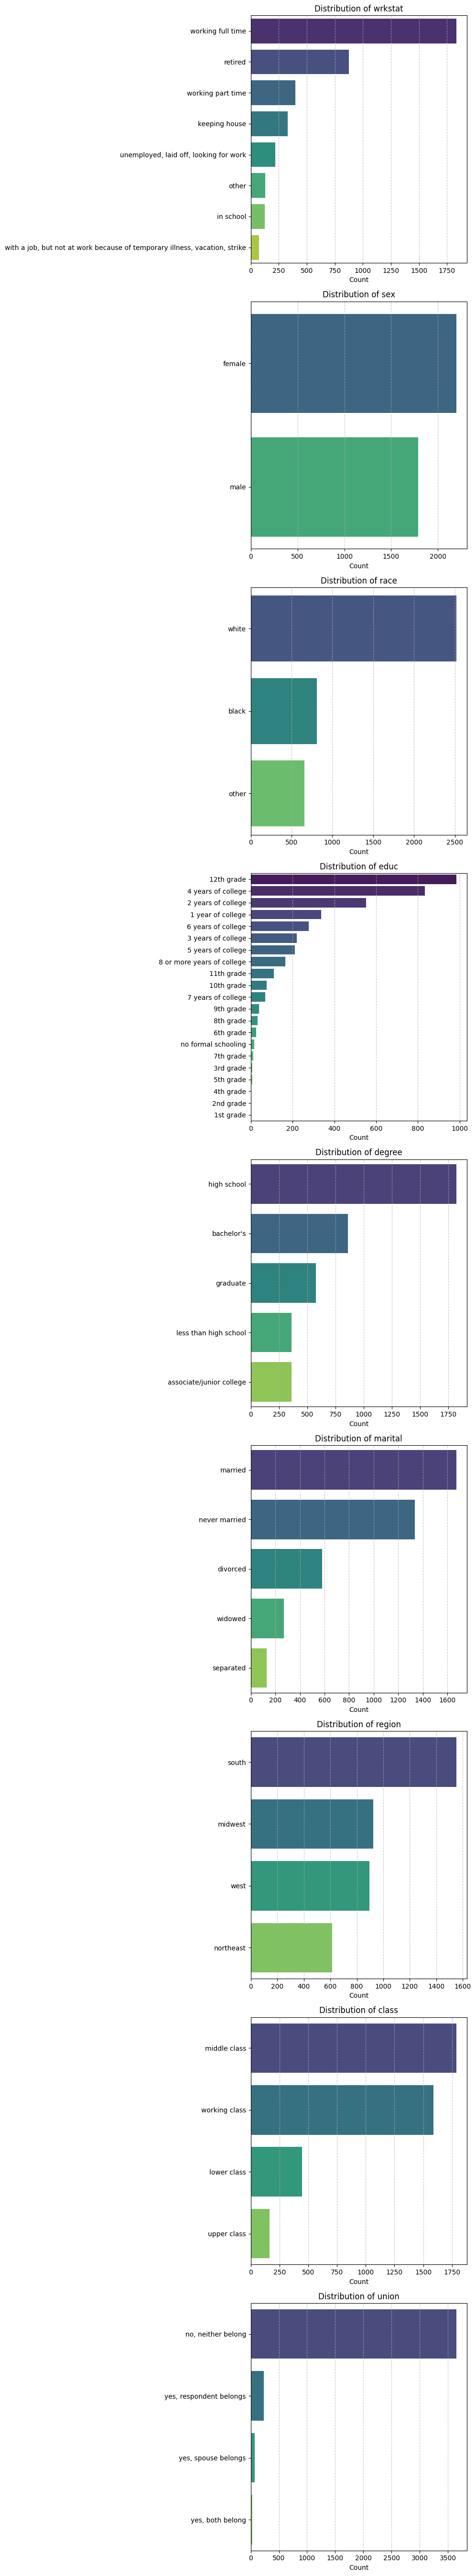

In [14]:
# List of categorical columns to explore
categorical_cols = [
    'wrkstat', 'sex', 'race', 'educ', 'degree', 'marital', 'region', 'class', 'union'
]

# Create subplots for each categorical feature
fig, axes = plt.subplots(nrows=len(categorical_cols), ncols=1, figsize=(10, 6 * len(categorical_cols)))
axes = axes.flatten() # Flatten in case there's only one subplot

for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index, palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Exploring Numerical Features

Next, let's examine the distributions of the numerical features. This will help us understand their ranges, central tendencies, and variability, and check for any potential outliers or skewed distributions.

/tmp/ipykernel_4053/2994543718.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[2*i], palette='viridis')
/tmp/ipykernel_4053/2994543718.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], ax=axes[2*i + 1], palette='viridis')
/tmp/ipykernel_4053/2994543718.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[2*i], palette='viridis')
/tmp/ipykernel_4053/2994543718.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], ax=axes[2*i + 1], palette='viridis')
/tmp/ipykernel_4053/2994543718.py:23: UserWarning: Ignoring `palette` 

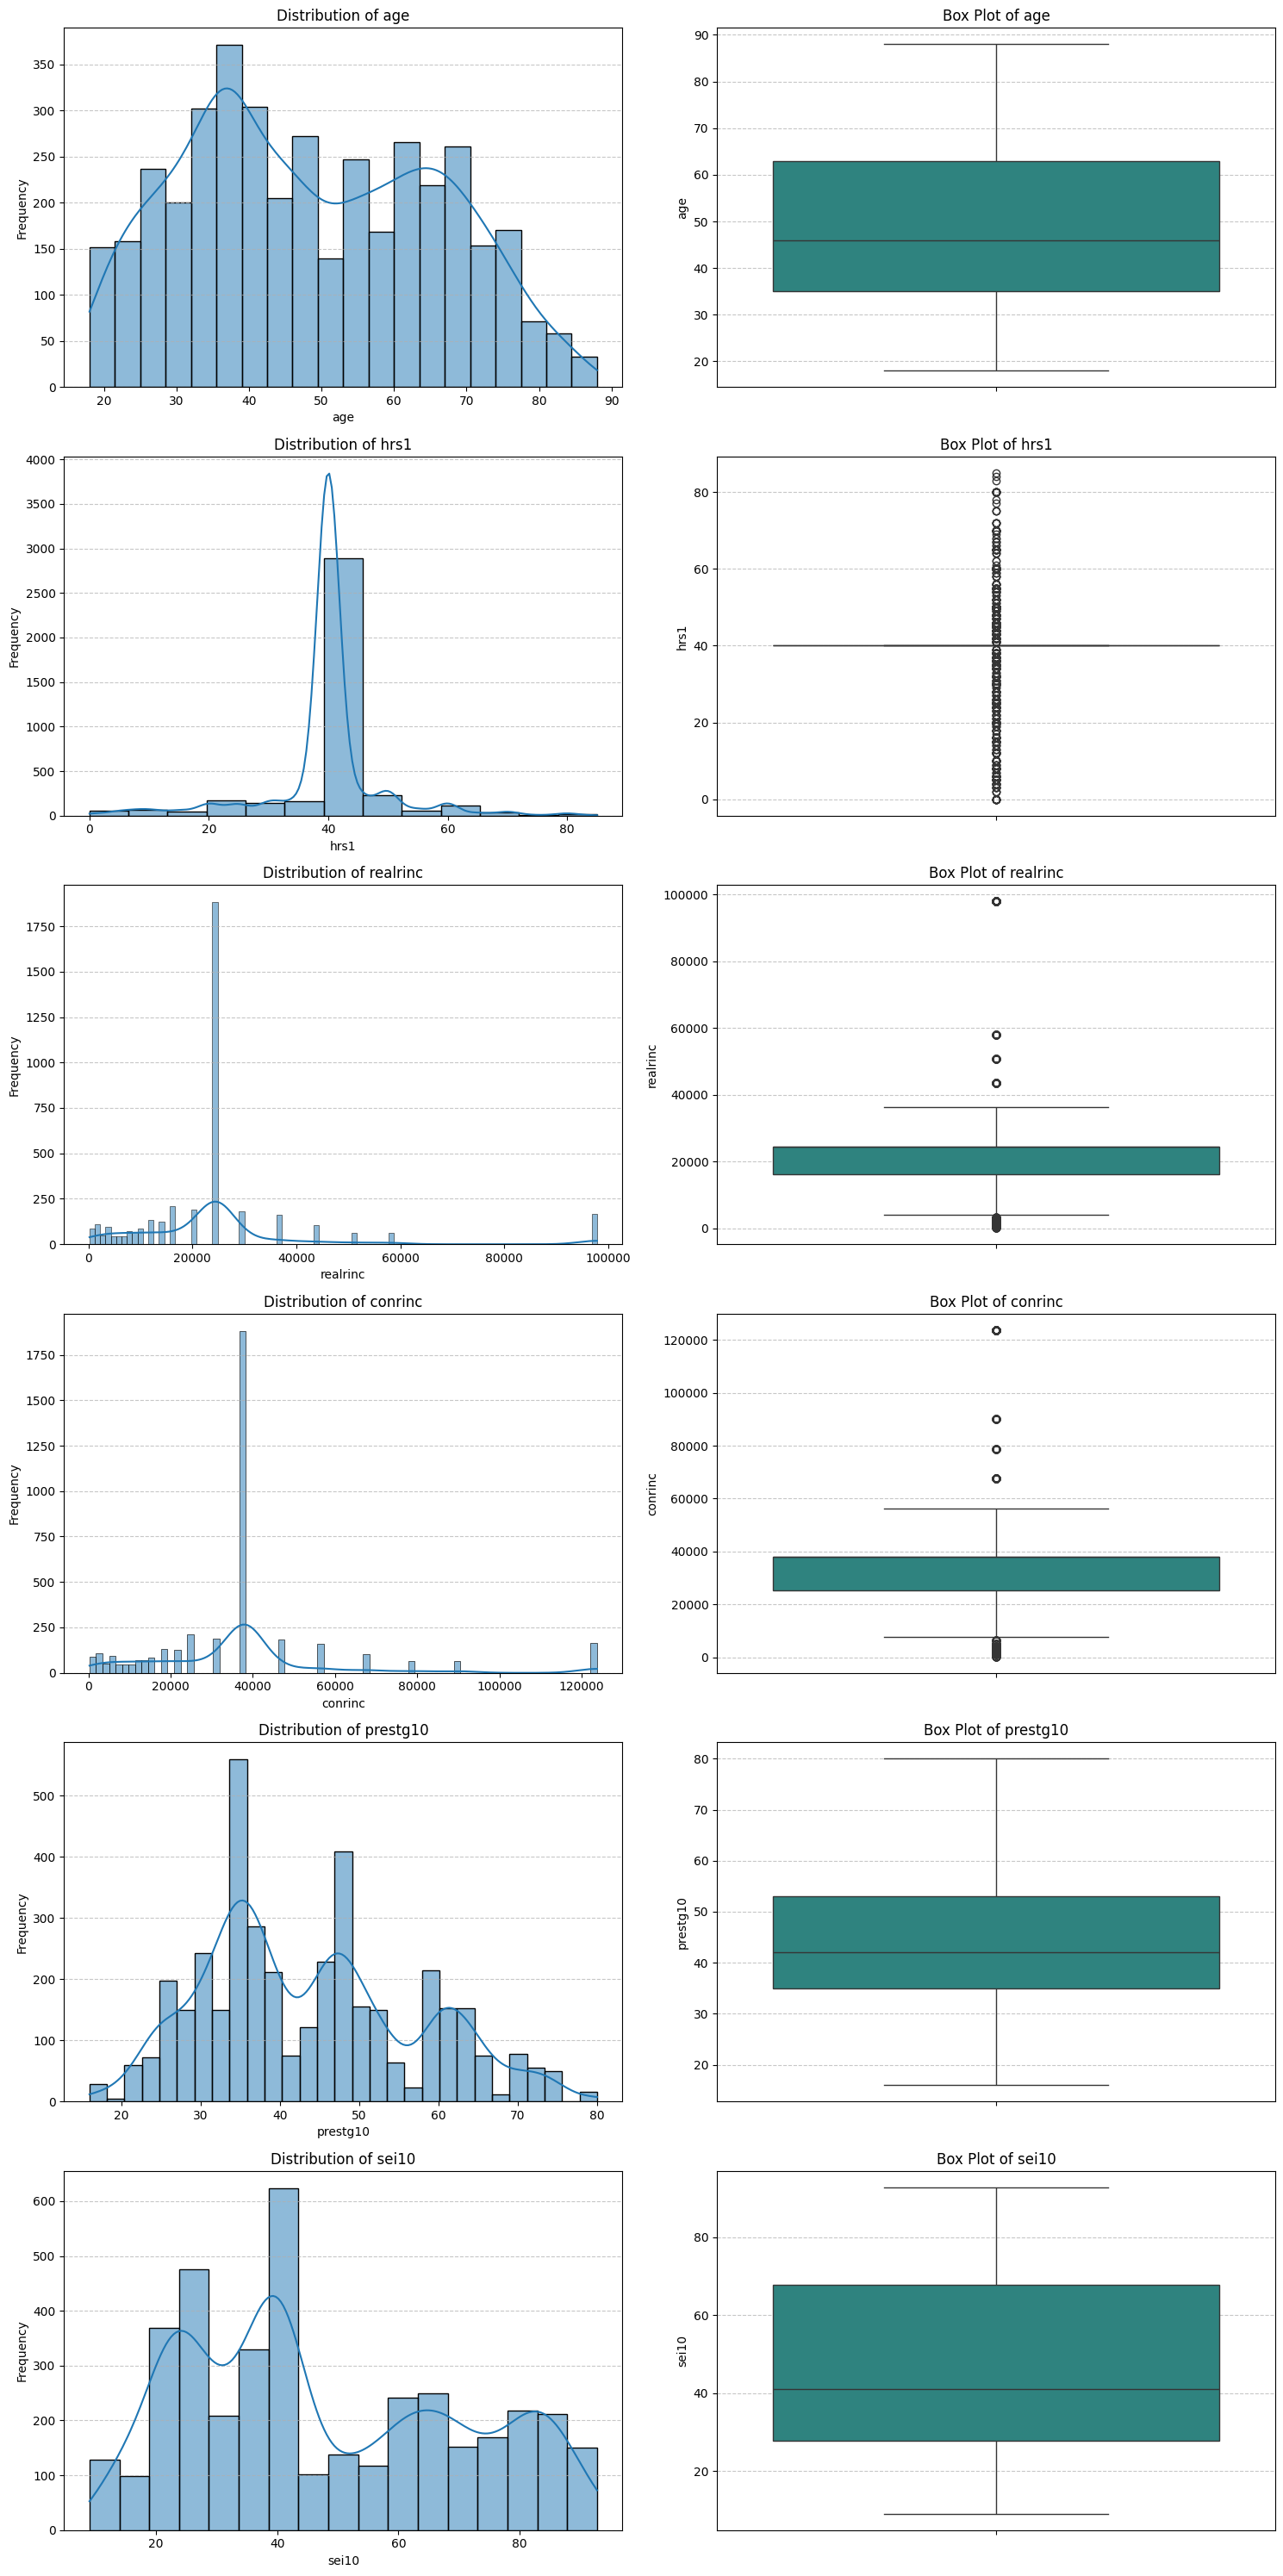

In [17]:
# List of numerical columns to explore, excluding 'income' and 'income16' for now
# as they contain string ranges that are not directly numeric.
numerical_cols = [
    'age', 'hrs1', 'realrinc', 'conrinc', 'prestg10', 'sei10'
]

# Ensure all numerical columns are indeed numeric, coercing errors
for col in numerical_cols:
    # Convert column to numeric, setting non-numeric values to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Impute newly created NaNs with the median
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Coerced and imputed '{col}' with median: {median_val}")

# Create subplots for each numerical feature
fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=2, figsize=(15, 5 * len(numerical_cols)))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    # Histogram for distribution
    sns.histplot(df[col], kde=True, ax=axes[2*i], palette='viridis')
    axes[2*i].set_title(f'Distribution of {col}')
    axes[2*i].set_xlabel(col)
    axes[2*i].set_ylabel('Frequency')
    axes[2*i].grid(axis='y', linestyle='--', alpha=0.7)

    # Box plot for outliers and spread
    sns.boxplot(y=df[col], ax=axes[2*i + 1], palette='viridis')
    axes[2*i + 1].set_title(f'Box Plot of {col}')
    axes[2*i + 1].set_xlabel('')
    axes[2*i + 1].set_ylabel(col)
    axes[2*i + 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Summary of Exploratory Data Analysis

We have completed the initial exploratory data analysis steps, including:

1.  **Data Loading and Initial Inspection**: Loaded the GSS dataset and selected relevant columns for job satisfaction analysis.
2.  **Job Satisfaction Metric Creation**: Cleaned and transformed the 'satjob' variable into a numerical 'job_satisfaction' metric, applying winsorization to handle outliers.
3.  **Missing Value Handling**: Imputed missing values for columns with low percentages using mode (categorical) or median (numerical). Columns with extremely high missing percentages (e.g., `hrs2`) were dropped. For numerical columns like `age`, `hrs1`, `realrinc`, `conrinc`, `prestg10`, and `sei10`, non-numeric entries were coerced to `NaN` and then imputed with their respective medians.
4.  **Categorical Feature Distributions**: Visualized the distributions of key categorical variables (`wrkstat`, `sex`, `race`, `educ`, `degree`, `marital`, `region`, `class`, `union`). This provides insights into the demographic and work-related composition of the dataset.
5.  **Numerical Feature Distributions**: Visualized the distributions of numerical variables (`age`, `hrs1`, `realrinc`, `conrinc`, `prestg10`, `sei10`) using histograms and box plots. This helped to understand their spread, central tendency, and identify potential outliers. It was noted that 'income' and 'income16' contained string ranges and were excluded from direct numerical plotting.

At this stage, our `df` DataFrame is clean and preprocessed, with missing values addressed and feature types confirmed for analysis. We have a good foundational understanding of the individual feature distributions.